# 🐄 Indian Cattle Breed Classification (50 Classes)
**Project Overview:** This project uses Transfer Learning with the **ConvNeXt-Tiny** architecture to classify 50 different breeds of Indian cattle.

**Key Features:**
* **Dataset:** A custom-merged dataset combining two major sources, deduplicated using MD5 hashing.
* **Augmentation:** Integrated `torchvision.transforms` for robust training.
* **Tech Stack:** PyTorch, Google Colab (T4 GPU), Mac M1 (Local Management).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import shutil
import hashlib
import tensorflow as tf
import keras
import os
from sklearn.utils import class_weight
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns

In [ ]:

# 1. Unzip Atharva dataset locally
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/atharva_local"

# 2. Copy the 'cattle' folder locally
!cp -r "/content/drive/MyDrive/cattle" "/content/luke_local"

# 3. Create a final Master folder
master_path = "/content/master_dataset"
os.makedirs(master_path, exist_ok=True)

to merge the two datasets without duplicate images

In [ ]:
def get_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

source_folders = ["/content/atharva_local", "/content/luke_local"]
seen_hashes = set()

for source in source_folders:
    # Walk through every breed subfolder
    for breed in os.listdir(source):
        src_breed_dir = os.path.join(source, breed)
        if not os.path.isdir(src_breed_dir): continue

        dst_breed_dir = os.path.join(master_path, breed)
        os.makedirs(dst_breed_dir, exist_ok=True)

        for img in os.listdir(src_breed_dir):
            img_path = os.path.join(src_breed_dir, img)
            try:
                h = get_hash(img_path)
                if h not in seen_hashes:
                    # Copy to the local master folder
                    shutil.copy(img_path, os.path.join(dst_breed_dir, f"{h}.jpg"))
                    seen_hashes.add(h)
            except:
                continue

print(f"Merge complete! Unique images in Master: {len(seen_hashes)}")

Merge complete! Unique images in Master: 7808


In [ ]:
master_dataset='/content/master_dataset'

In [ ]:
breed_count={}
for breed_name in os.listdir(master_dataset):
  breed_folder_path= os.path.join(master_dataset,breed_name)

  # making sure that it's a dir and not ds.store or something else
  if os.path.isdir(breed_folder_path):
    breed_count[breed_name]=len(os.listdir(breed_folder_path))

In [ ]:
sorted_counts = sorted(breed_count.items(), key=lambda x: x[1])
# .items() make the dict in [('breed_name',count),(),()] format and x:x[1] tell it to look at the second element i.e count to sort
print("Breeds that need the most help:", sorted_counts[:5])


Breeds that need the most help: [('Nimari', 83), ('Lakhimi', 92), ('gaolao', 94), ('dagri', 96), ('Malnad_gidda', 98)]


In [ ]:
!rm -rf "/content/master_dataset/Indian_bovine_breeds"

In [ ]:
len(breed_count.values())

50

In [ ]:
breed_count.values()

dict_values([134, 233, 180, 220, 104, 182, 172, 218, 126, 138, 152, 134, 119, 174, 177, 331, 164, 189, 132, 119, 136, 207, 104, 117, 168, 103, 96, 120, 164, 127, 176, 83, 94, 168, 92, 418, 118, 138, 148, 170, 105, 152, 142, 159, 98, 136, 205, 155, 199, 112])

In [ ]:
train_ds= tf.keras.utils.image_dataset_from_directory(
    master_dataset,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds= tf.keras.utils.image_dataset_from_directory(
    master_dataset,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 7808 files belonging to 50 classes.
Using 6247 files for training.
Found 7808 files belonging to 50 classes.
Using 1561 files for validation.


In [ ]:
data_aug= tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [ ]:

keras.config.set_dtype_policy('mixed_float16')

In [ ]:
early_stopping= tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                 patience=3,
                                                 )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                 factor=0.2, # multiply the learning rate by 0.2 (reduce by 5x)
                                                 patience=3,
                                                 verbose=1, # print out when learning rate goes down
                                                 min_lr=1e-7)

In [ ]:

master_path = "/content/master_dataset"
breeds = sorted([d for d in os.listdir(master_path) if os.path.isdir(os.path.join(master_path, d))])
all_labels = []
for i, breed in enumerate(breeds):
    count = len(os.listdir(os.path.join(master_path, breed)))
    all_labels.extend([i] * count)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weights_dict = dict(enumerate(weights))
print(f"Total Breeds: {len(breeds)}")
min_breed = min(breeds, key=lambda b: len(os.listdir(os.path.join(master_path, b))))
max_breed = max(breeds, key=lambda b: len(os.listdir(os.path.join(master_path, b))))

print(f"Highest Weight (for {min_breed}): {max(weights):.2f}")
print(f"Lowest Weight (for {max_breed}): {min(weights):.2f}")

Total Breeds: 50
Highest Weight (for Nimari): 1.88
Lowest Weight (for Sahiwal): 0.37


In [ ]:

@tf.keras.utils.register_keras_serializable()
def sparse_categorical_crossentropy_with_smoothing(y_true, y_pred):
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=50)
    return tf.keras.losses.categorical_crossentropy(
        y_true_one_hot,
        y_pred,
        label_smoothing=0.1
    )

In [ ]:
base_model_conv = tf.keras.applications.ConvNeXtTiny(
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
    input_shape=(224, 224, 3)
)
base_model_conv.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name='input_layer')
x = data_aug(inputs)
x = base_model_conv(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name='avg_pool')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5, name='top_dropout_1')(x) # High dropout to prevent overfitting

x = tf.keras.layers.Dense(256, activation='gelu', name='dense_refinement')(x) # ConvNeXt uses GELU
x = tf.keras.layers.Dropout(0.3, name='top_dropout_2')(x)

outputs = tf.keras.layers.Dense(50, activation='softmax', name='output_layer', dtype='float32')(x)

model_conv = tf.keras.Model(inputs, outputs)

model_conv.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_categorical_crossentropy_with_smoothing, # this tells the model to not be 100% confident and Improves F1 Scores
    metrics=['accuracy']
)

# Phase 1 Training (10 Epochs)
history_conv_1 = model_conv.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

In [ ]:

base_model_conv.trainable = True

for layer in base_model_conv.layers[:-30]:
    layer.trainable = False

model_conv.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=sparse_categorical_crossentropy_with_smoothing,
    metrics=['accuracy']
)

# Phase 2 Training (Continue from epoch 10)
history_conv_2 = model_conv.fit(
    train_ds,
    epochs=50,
    initial_epoch=10,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 200s 737ms/step - accuracy: 0.4561 - loss: 2.3720 - val_accuracy: 0.5477 - val_loss: 2.0421 - learning_rate: 1.0000e-05
Epoch 12/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 78s 396ms/step - accuracy: 0.4683 - loss: 2.3058 - val_accuracy: 0.5599 - val_loss: 2.0162 - learning_rate: 1.0000e-05
Epoch 13/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 395ms/step - accuracy: 0.4809 - loss: 2.2695 - val_accuracy: 0.5625 - val_loss: 2.0025 - learning_rate: 1.0000e-05
Epoch 14/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 67s 342ms/step - accuracy: 0.4964 - loss: 2.2265 - val_accuracy: 0.5663 - val_loss: 1.9921 - learning_rate: 1.0000e-05
Epoch 15/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 345ms/step - accuracy: 0.5021 - loss: 2.2160 - val_accuracy: 0.5663 - val_loss: 1.9823 - learning_rate: 1.0000e-05
Epoch 16/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 345ms/step - accuracy: 0.4993 - loss: 2.1860 - val_accuracy: 0.5714 - val_loss: 1.9743 - learning_rate: 1.0000e-05
Epoch 17/50
196/196 ━━━━━━━━━━━━━━━━━━━

In [ ]:
model_conv.evaluate(val_ds)

49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6213 - loss: 1.8500


[1.8258124589920044, 0.6303651332855225]

In [ ]:
model_conv.save('/content/drive/MyDrive/convnext_model_on_drive.keras')

## Training the previous convNet model for longer epochs

In [ ]:
new_callbacks=[
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                     patience=10,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                         factor=0.2,
                                         patience=3,
                                         verbose=1,
                                         min_lr=1e-7)
]

In [ ]:
model_convNet= tf.keras.models.load_model('/content/drive/MyDrive/convnext_model_on_drive.keras')

In [ ]:
model_convNet.evaluate(val_ds)

49/49 ━━━━━━━━━━━━━━━━━━━━ 67s 777ms/step - accuracy: 0.7153 - loss: 1.5799


[1.595164179801941, 0.713004469871521]

In [ ]:
model_convNet.fit(
    train_ds,
    initial_epoch=50,
    epochs=100,
    validation_data=val_ds,
    validation_steps= int(0.20 * len(val_ds)),
    callbacks=new_callbacks
)

Epoch 51/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 118s 390ms/step - accuracy: 0.6203 - loss: 1.8903 - val_accuracy: 0.6771 - val_loss: 1.6372 - learning_rate: 1.0000e-05
Epoch 52/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 61s 309ms/step - accuracy: 0.6171 - loss: 1.8909 - val_accuracy: 0.6979 - val_loss: 1.6137 - learning_rate: 1.0000e-05
Epoch 53/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 309ms/step - accuracy: 0.6250 - loss: 1.8733 - val_accuracy: 0.7222 - val_loss: 1.5984 - learning_rate: 1.0000e-05
Epoch 54/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 415ms/step - accuracy: 0.6189 - loss: 1.8667 - val_accuracy: 0.6979 - val_loss: 1.6304 - learning_rate: 1.0000e-05
Epoch 55/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 61s 309ms/step - accuracy: 0.6258 - loss: 1.8720 - val_accuracy: 0.7118 - val_loss: 1.6318 - learning_rate: 1.0000e-05
Epoch 56/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6394 - loss: 1.8503
Epoch 56: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
196/196 ━━━━━━━━━━━━━━━━━━

In [ ]:
model_convNet.evaluate(val_ds) # the accuracy did'nt improve much just by training it for longer

49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.7219 - loss: 1.5823


[1.5579580068588257, 0.7341448068618774]

In [ ]:
model= tf.keras.models.load_model('/content/drive/MyDrive/convnext_model_improved.keras')

In [ ]:
model.evaluate(val_ds)

In [ ]:
model.trainable=True
for i in model.layers[:-60]:
  i.trainable=False

In [ ]:
new_callbacks=[
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                     patience=10,
                                     restore_best_weights=True
                                     ),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                         factor=0.2,
                                         patience=3,
                                         verbose=1,
                                         min_lr=1e-7)
]

In [ ]:
base_model_conv_in_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "convnext" in layer.name.lower(): # Check layer type and name
        base_model_conv_in_model = layer
        break

if base_model_conv_in_model:
    base_model_conv_in_model.trainable = True # Unfreeze the entire base model
    for layer in base_model_conv_in_model.layers:
        layer.trainable = True # Ensure all sub-layers are also trainable
    print("Entire ConvNeXtTiny base model unfrozen.")
else:
    print("Error: ConvNeXtTiny base model not found in the loaded model structure.")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Very low learning rate
    loss=sparse_categorical_crossentropy_with_smoothing,
    metrics=['accuracy']
)

Entire ConvNeXtTiny base model unfrozen.


In [ ]:
model.fit(
    train_ds,
    initial_epoch=100,
    epochs=150,
    validation_data=val_ds,
    validation_steps= int(0.20 * len(val_ds)),
    callbacks=new_callbacks
)

Epoch 101/150
196/196 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.6564 - loss: 1.7738 - val_accuracy: 0.7674 - val_loss: 1.4729 - learning_rate: 1.0000e-06
Epoch 102/150
196/196 ━━━━━━━━━━━━━━━━━━━━ 139s 707ms/step - accuracy: 0.6569 - loss: 1.7942 - val_accuracy: 0.7500 - val_loss: 1.4527 - learning_rate: 1.0000e-06
Epoch 103/150
196/196 ━━━━━━━━━━━━━━━━━━━━ 138s 699ms/step - accuracy: 0.6615 - loss: 1.7761 - val_accuracy: 0.7257 - val_loss: 1.5011 - learning_rate: 1.0000e-06
Epoch 104/150
196/196 ━━━━━━━━━━━━━━━━━━━━ 137s 697ms/step - accuracy: 0.6648 - loss: 1.7604 - val_accuracy: 0.7465 - val_loss: 1.5195 - learning_rate: 1.0000e-06
Epoch 105/150
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.6561 - loss: 1.7782
Epoch 105: ReduceLROnPlateau reducing learning rate to 1.9999999949504855e-07.
196/196 ━━━━━━━━━━━━━━━━━━━━ 142s 723ms/step - accuracy: 0.6561 - loss: 1.7783 - val_accuracy: 0.7326 - val_loss: 1.5170 - learning_rate: 1.0000e-06
Epoch 106/150
196/196 ━━━━━━━━━━

In [ ]:
model.evaluate(val_ds)

48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7396 - loss: 1.4912

Gathering predictions from validation set...


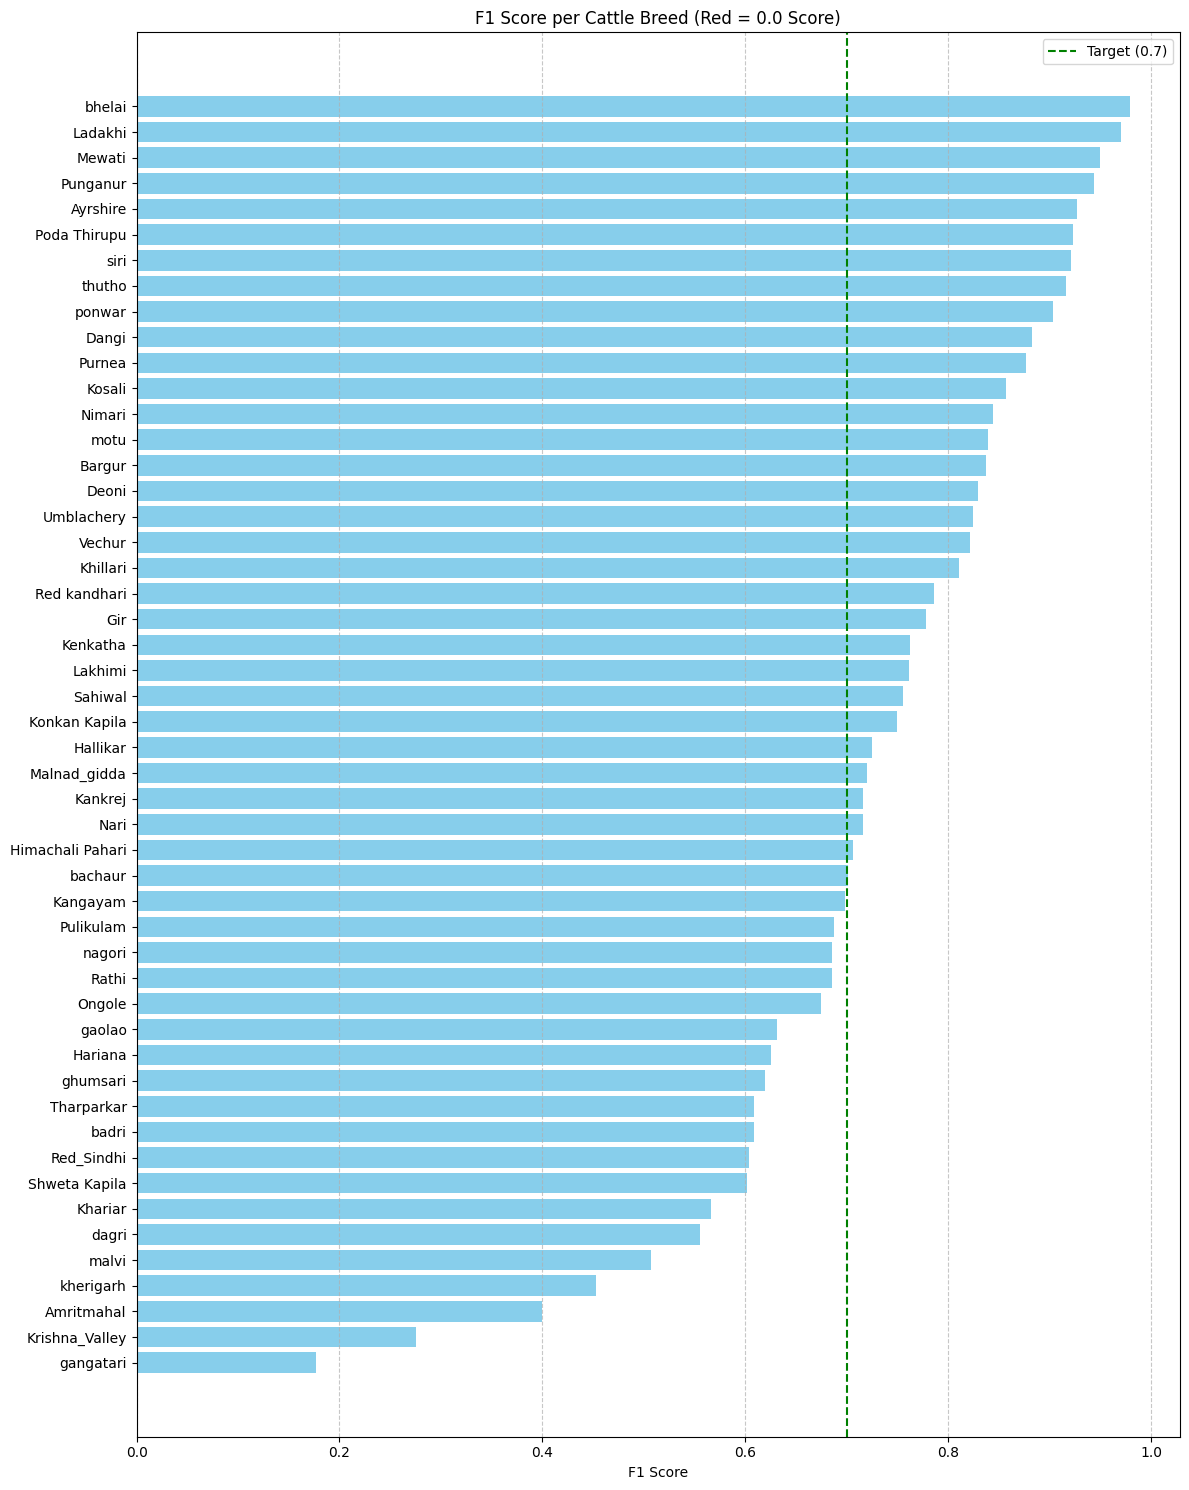

In [ ]:
y_true = []
y_pred = []

print("Gathering predictions from validation set...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
report = classification_report(y_true, y_pred, target_names=val_ds.class_names, output_dict=True)

df_report = pd.DataFrame(report).transpose()
breed_f1 = df_report.iloc[:-3, :]['f1-score'].sort_values()
plt.figure(figsize=(12, 15))
colors = sns.color_palette("viridis", len(breed_f1))
color_map = ['red' if score == 0 else 'skyblue' for score in breed_f1]

plt.barh(breed_f1.index, breed_f1.values, color=color_map)
plt.axvline(x=0.7, color='green', linestyle='--', label='Target (0.7)')
plt.xlabel('F1 Score')
plt.title('F1 Score per Cattle Breed (Red = 0.0 Score)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()